<a href="https://colab.research.google.com/github/pifanocvs/ds-learning-hub/blob/main/transfer_learning_dio_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Esse notebook foi feito no intuito de concluir o projeto "Treinamento de Redes Neurais com Transfer Learning" do Bootcamp "[BairesDev](https://www.bairesdev.com/) - Machine Learning Practitioner" da [DIO](DIO.io)


Atividade:
O projeto consiste em aplicar o método de Transfer Learning em uma rede de Deep Learning na linguagem Python no ambiente COLAB.  

Para exemplo, utilizaremos o seguinte projeto que realiza Transfer Learning com o Dataset do MNIST:
https://colab.research.google.com/github/kylemath/ml4a-guides/blob/master/notebooks/transfer-learning.ipynb

O dataset utilizado engloba duas classes: gatos e cachorros. Uma descrição da base de dados pode ser visualizada neste link: https://www.tensorflow.org/datasets/catalog/cats_vs_dogs.

Já o dataset para download pode ser acessado por meio deste outro link:

https://www.microsoft.com/en-us/download/details.aspx?id=54765.



Observações: Neste projeto, você pode usar sua própria base de dados (exemplo: fotos suas, dos seus pais, dos seus amigos, dos seus animais domésticos, etc), o exemplo de gatos e cachorros, pode ser substituído por duas outras classes do seu interesse. **O Dataset criado em nosso projeto anterior, pode ser utilizado agora.**

O projeto deve ser enviado para o GitHub da DIO: https://github.com/digitalinnovationone.

## Projeto

###Dataset Usado:
Criado no projeto anterior, contendo 200 imagens:
100 cookies e 100 pizzas

Disponibilizado no drive:
[root](/content/drive/MyDrive/projetos/dio/bootcamp_ml_baires)

## Importanto Libs

In [38]:
#mesmo bloco do collab exemplo

'''
comando de backend no ipynb que ativa a renderização do matplot diretamente
abaixo dos blocos de codigo, ou seja quando executado, os graficos da lib
são exibidos no notebook ao invés de em uma janela diferente ou bloco de saida
'''
%matplotlib inline

#importado para uso de comando de so
import os

#lib interna de randomização
import random
#lib matematica muito usada para ml
import numpy as np
#lib de rede neural com conexão direta ao tensorflow
import keras

#lib e modulo de graficos e exibição de imagem
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

#modulos especificos da lib keras
from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

## Importando o Dataset
*teste se do drive vai ~ por enquanto foi*

In [39]:
#dataset
root = "/content/drive/MyDrive/projetos/dio/bootcamp_ml_bairesdev/dataset"
#separação para treinamento 70/15
train_split, val_split = 0.7, 0.15

categories = [x[0] for x in os.walk(root) if x[0]][1:]
categories = [c for c in categories]

print(categories)

['/content/drive/MyDrive/projetos/dio/bootcamp_ml_bairesdev/dataset/cookie', '/content/drive/MyDrive/projetos/dio/bootcamp_ml_bairesdev/dataset/pizza']


Função útil para pre-processamento dos dados em imagem e vetor de entrada (tradução livre)

In [40]:
# função auxiliadora para carregar imagem e devolver e vetor de entrada
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x

Carregar todas as imagens do dataset

In [41]:
# lista vazia pros dados
data = []
#loop para realizar o carregamento
for c, category in enumerate(categories):
    images = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg','.webp']]
    for img_path in images:
        img, x = get_image(img_path)
        data.append({'x':np.array(x[0]), 'y':c})

# usa mais pra frente
num_classes = len(categories)

Aleatorizando a ordem dos dados

In [42]:
random.shuffle(data)

Cria treinamento/validação/teste
Split 70, 15, 15

In [43]:
idx_val = int(train_split * len(data))
idx_test = int((train_split + val_split) * len(data))
train = data[:idx_val]
val = data[idx_val:idx_test]
test = data[idx_test:]

Separar dados pra rótulos

In [44]:
x_train, y_train = np.array([t["x"] for t in train]), [t["y"] for t in train]
x_val, y_val = np.array([t["x"] for t in val]), [t["y"] for t in val]
x_test, y_test = np.array([t["x"] for t in test]), [t["y"] for t in test]
print(y_test)

[1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0]


Pré-processamento de dados como anteriormente ao se certificar que é float32(permite armazenar numeros decimais, ocupa 32bits ou 4 bytes por pixel) e normalizado entre 0 e 1.

In [45]:
# normalizando os dados
x_train = x_train.astype('float32') / 255.
x_val = x_val.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# converta rótulos para 1xN vector
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test.shape)

(30, 2)


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sumarizando o que se tem até o momento
-> extremamente importante!!!
me ajudou a identificar problemas em quantas imagens sendo processadas.

In [47]:
print("finished loading %d images from %d categories"%(len(data), num_classes))
print("train / validation / test split: %d, %d, %d"%(len(x_train), len(x_val), len(x_test)))
print("training data shape: ", x_train.shape)
print("training labels shape: ", y_train.shape)

finished loading 200 images from 2 categories
train / validation / test split: 140, 30, 30
training data shape:  (140, 224, 224, 3)
training labels shape:  (140, 2)


Olhando algumas imagens

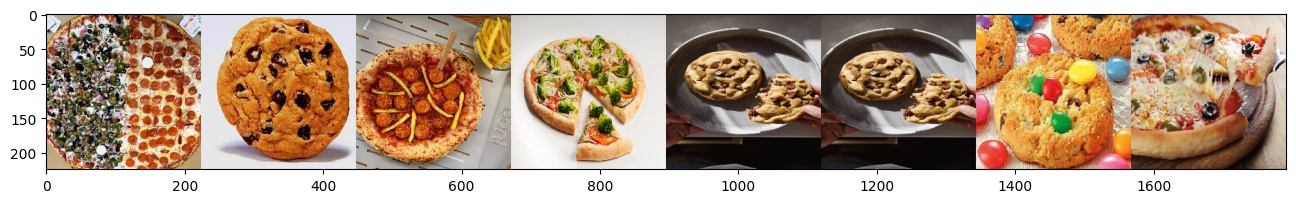

In [48]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg', '.webp']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [image.load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

## Primeiro Treinamento de Rede Neural do Zero :)

Antes de fazer o tranfer learning, será necessário construir uma rede neural do zero fazendo cafficação no dataset. Isso dará uma vase para comparar com a rede tranfer-learned depois.

(tradução livre)

In [49]:
#construção da rede
#comentários do copilot para compreender melhor

#cria um modelo sequencial, que é uma pilha linear de camadas.
model = Sequential()
#imprime as dimensões da entrada, que são as dimensões das imagens de treino, excluindo o número de amostras.
print("Input dimensions: ",x_train.shape[1:])

#adiciona uma camada convolucional com 32 filtros de tamanho 3x3. A input_shape define a forma da entrada.
model.add(Conv2D(32, (3, 3), input_shape=x_train.shape[1:]))
#adiciona uma função de ativação ReLU (Rectified Linear Unit) para introduzir não-linearidade.
model.add(Activation('relu'))
#adiciona uma camada de pooling máximo com uma janela de 2x2 para reduzir a dimensionalidade espacial.
model.add(MaxPooling2D(pool_size=(2, 2)))

#adiciona outra camada convolucional com 32 filtros de tamanho 3x3.
model.add(Conv2D(32, (3, 3)))
#adiciona uma função de ativação ReLU.
model.add(Activation('relu'))
#adiciona uma camada de pooling máximo com uma janela de 2x2.
model.add(MaxPooling2D(pool_size=(2, 2)))

#adiciona uma camada de dropout com uma taxa de 25% para evitar overfitting,
#desativando aleatoriamente 25% dos neurônios durante o treinamento.
model.add(Dropout(0.25))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

#adiciona outra camada de dropout com uma taxa de 25%.
model.add(Flatten())
#adiciona uma camada densa (totalmente conectada) com 256 neurônios.
model.add(Dense(256))
model.add(Activation('relu'))

model.add(Dropout(0.5))

#adiciona uma camada densa com um número de neurônios igual ao número de classes (saídas).
model.add(Dense(num_classes))
#adiciona uma função de ativação softmax para obter probabilidades de cada classe.
model.add(Activation('softmax'))

model.summary()

Input dimensions:  (224, 224, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 222, 222, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 109, 109, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 109, 109, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 52, 52, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 52, 52, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 24, 24, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             514 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,209,058 (4.61 MB)

 Trainable params: 1,209,058 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

Agora pode ir a diante e treinar o modelo por 100 epochs com batch-128

In [57]:
# compila o modelo para usar função de perda de entropia cruzada categórica e otimizador adadelta
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_data=(x_val, y_val))


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9394 - loss: 0.1584 - val_accuracy: 0.7667 - val_loss: 0.5816
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9389 - loss: 0.1393 - val_accuracy: 0.7333 - val_loss: 0.7146
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7769 - loss: 0.4701 - val_accuracy: 0.7667 - val_loss: 0.4583
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9263 - loss: 0.1731 - val_accuracy: 0.8000 - val_loss: 0.4660
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9632 - loss: 0.1386 - val_accuracy: 0.7667 - val_loss: 0.5577
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9216 - loss: 0.2128 - val_accuracy: 0.7667 - val_loss: 0.5247
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9411 - loss: 0.1731 - val_accuracy: 0.7333 - val_loss: 0.4443
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9558 - loss: 0.1315 - val_accuracy: 0.7667 - val_loss: 0.4929
Epoch 9/

Agora plotar a validação da perda e validação sobre o tempo

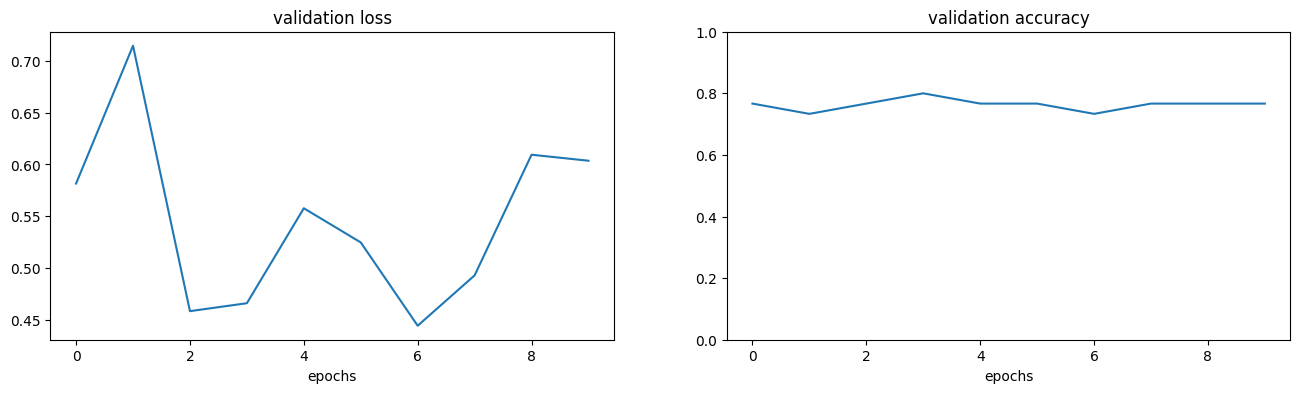

In [63]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
# No TensorFlow/Keras a partir da versão 2.0, a chave da métrica é val_accuracy em vez de val_acc
# No cod original tava dando erro por estar val_acc
ax2.plot(history.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

Observe que a perda de validação começa a aumentar após cerca de 16 épocas, embora a precisão da validação permaneça aproximadamente entre 40% e 50%. Isso sugere que nosso modelo começa a se ajustar demais nessa época, e o melhor desempenho teria sido alcançado se tivéssemos parado mais cedo nessa época. No entanto, a nossa precisão provavelmente não teria sido superior a 50%, e provavelmente inferior.

Também podemos obter uma avaliação final executando nosso modelo no conjunto de treinamento. Fazendo isso, obtemos os seguintes resultados:

In [64]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.305982768535614
Test accuracy: 0.8666666746139526


Finally, we see that we have achieved a (top-1) accuracy of around 49%. That's not too bad for 6000 images, considering that if we were to use a naive strategy of taking random guesses, we would have only gotten around 1% accuracy.

## Transfer learning ao começar com uma rede existente

Agora podemos prosseguir para a estrategia principal para o treinamento de uma classificador de imagem no nosso dataset menos, ao usar uma rede maior e já treinada.
Para começar, nós carregaremos o VGG16 de Keras, no qual foi treinada no ImageNet e os tamanhos salvos online. Sendo essa a minha primeira vez carregando o VGG15, será necessário esperar o donwload da internet. Depois de lodado, será possível inspecionar as camadas através do método de sumario.


In [65]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Observe que o VGG16 é muito maior do que a rede que construímos anteriormente. Ele contém 13 camadas convolucionais e duas camadas totalmente conectadas no final, e tem mais de 138 milhões de parâmetros, cerca de 100 vezes mais parâmetros do que a rede que fizemos acima. Como nossa primeira rede, a maioria dos parâmetros é armazenada nas conexões que levam à primeira camada totalmente conectada.

O VGG16 foi feito para resolver o ImageNet e atinge uma taxa de erro top-5 de 8,8%, o que significa que 91,2% das amostras de teste foram classificadas corretamente dentro das 5 principais previsões para cada imagem. Sua precisão top-1 — equivalente à métrica de precisão que temos usado (que a previsão superior está correta) — é de 73%. Isso é especialmente impressionante, pois não há apenas 97, mas 1000 classes, o que significa que palpites aleatórios nos dariam apenas 0,1% de precisão.

Para usar essa rede para nossa tarefa, "removemos" a camada de classificação final, a camada softmax de 1000 neurônios no final, que corresponde ao ImageNet, e a substituímos por uma nova camada softmax para nosso conjunto de dados, que contém 97 neurônios no caso do conjunto de dados 101_ObjectCategories.

Em termos de implementação, é mais fácil simplesmente criar uma cópia do VGG de sua camada de entrada até a segunda para a última camada, e então trabalhar com isso, em vez de modificar o objeto VGG diretamente. Então, tecnicamente, nunca "removemos" nada, apenas contornamos/ignoramos. Isso pode ser feito da seguinte maneira, usando a classe keras Model para inicializar um novo modelo cuja camada de entrada é a mesma que VGG, mas cuja camada de saída é nossa nova camada softmax, chamada new_classification_layer. Nota: embora pareça que estamos duplicando essa grande rede, internamente o Keras está na verdade apenas copiando todas as camadas por referência e, portanto, não precisamos nos preocupar em sobrecarregar a memória.

(traduzido com o google mesmo)

In [66]:
# faz uma referencia a camada input VGG
inp = vgg.input

# faz uma nova camada softmax com neuronios num_classes
new_classification_layer = Dense(num_classes, activation='softmax')

# conecta nossa nova camada com a segunda até a última camada em VGG, e fazer referencia a isso
out = new_classification_layer(vgg.layers[-2].output)

# cria a nova rede entre inp e out
model_new = Model(inp, out)

Vamos treinar novamente esta rede, model_new, no novo conjunto de dados e rótulos. Mas primeiro, precisamos congelar os pesos e vieses em todas as camadas da rede, exceto a nova no final, com a expectativa de que os recursos que foram aprendidos no VGG ainda sejam bastante relevantes para a nova tarefa de classificação de imagem. Não é o ideal, mas provavelmente é melhor do que podemos treinar em nosso conjunto de dados limitado.

Ao definir o sinalizador treinável em cada camada como falso (exceto nossa nova camada de classificação), garantimos que todos os pesos e vieses nessas camadas permaneçam fixos e simplesmente treinamos os pesos na camada no final. Em alguns casos, é desejável não congelar todas as camadas de pré-classificação. Se seu conjunto de dados tiver amostras suficientes e não se parecer muito com o ImageNet, pode ser vantajoso ajustar algumas das camadas do VGG junto com o novo classificador, ou possivelmente até mesmo todas elas. Para fazer isso, você pode alterar o código abaixo para tornar mais camadas treináveis.

No caso do CalTech-101, faremos apenas a extração de recursos, temendo que o ajuste fino demais com esse conjunto de dados possa sobreajustar. Mas talvez estejamos errados? Um bom exercício seria experimentar os dois e comparar os resultados.

Então, vamos em frente e congelamos as camadas e compilamos o novo modelo com exatamente o mesmo otimizador e função de perda da nossa primeira rede, para fins de uma comparação justa. Em seguida, executamos o resumo novamente para analisar a arquitetura da rede.

(traduzido do google mesmo)

In [67]:
# faz com que todas as camadas não treinadas tenham os pesos congelados, com exceção da última
for l, layer in enumerate(model_new.layers[:-1]):
    layer.trainable = False

# certifica-se que a última camada seja treinada/não congelada
for l, layer in enumerate(model_new.layers[-1:]):
    layer.trainable = True

model_new.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_new.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 8,194 (32.01 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

Olhando para o resumo, vemos que a rede é idêntica ao modelo VGG que instanciamos anteriormente, exceto que a última camada, anteriormente um softmax de 1000 neurônios, foi substituída por um novo softmax de 97 neurônios. Além disso, ainda temos aproximadamente 134 milhões de pesos, mas agora a grande maioria deles são "parâmetros não treináveis" porque congelamos as camadas em que estão contidos. Agora temos apenas 397.000 parâmetros treináveis, o que na verdade é apenas um quarto do número de parâmetros necessários para treinar o primeiro modelo.

Como antes, seguimos em frente e treinamos o novo modelo, usando os mesmos hiperparâmetros (tamanho do lote e número de épocas) de antes, junto com o mesmo algoritmo de otimização. Também monitoramos seu histórico à medida que avançamos.

In [68]:
history2 = model_new.fit(x_train, y_train,
                         batch_size=128,
                         epochs=10,
                         validation_data=(x_val, y_val))

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 119s 30s/step - accuracy: 0.6079 - loss: 0.6979 - val_accuracy: 0.5333 - val_loss: 0.6887
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 111s 29s/step - accuracy: 0.5147 - loss: 0.6807 - val_accuracy: 0.5000 - val_loss: 1.0178
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 152s 29s/step - accuracy: 0.4974 - loss: 1.0294 - val_accuracy: 0.7667 - val_loss: 0.5495
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 137s 28s/step - accuracy: 0.8141 - loss: 0.5227 - val_accuracy: 0.5000 - val_loss: 0.8286
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 139s 31s/step - accuracy: 0.4948 - loss: 0.7596 - val_accuracy: 0.8000 - val_loss: 0.5507
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 140s 28s/step - accuracy: 0.7721 - loss: 0.4910 - val_accuracy: 0.6333 - val_loss: 0.5194
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 146s 30s/step - accuracy: 0.7747 - loss: 0.4752 - val_accuracy: 0.7667 - val_loss: 0.4758
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 125s 28s/step - accuracy: 0.8410 - loss: 0.4193 - val_accuracy: 0.8333 - val_loss:

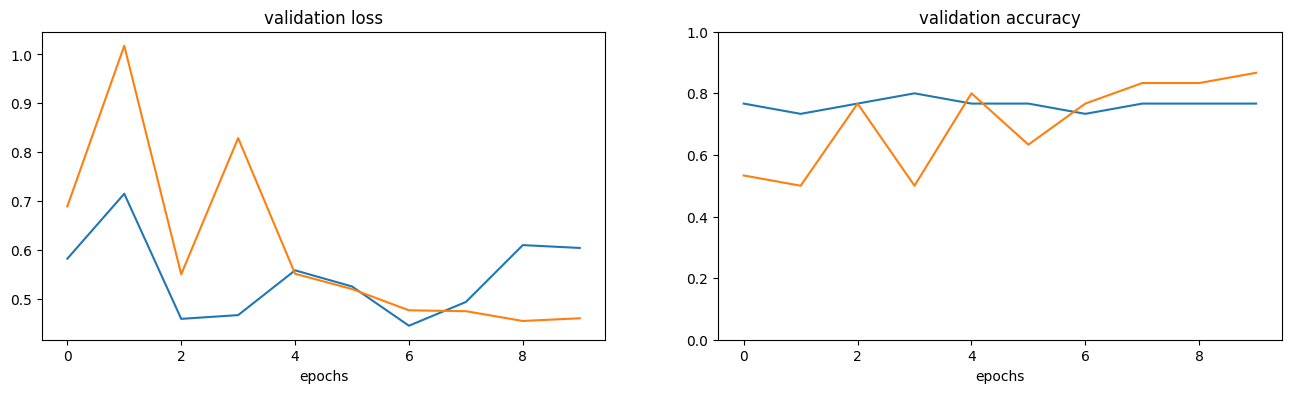

In [69]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.plot(history2.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"])
ax2.plot(history2.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

In [70]:
loss, accuracy = model_new.evaluate(x_test, y_test, verbose=0)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.4150603711605072
Test accuracy: 0.8999999761581421


In [72]:
img, x = get_image('/content/drive/MyDrive/projetos/dio/bootcamp_ml_bairesdev/dataset/cookie/003.jpg')
probabilities = model_new.predict([x])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
